## Stage 4 — DistilBERT (Transformer)



##### Install transformers 
##### Run this ONCE if transformers is not installed, then comment it out

In [1]:
# !pip install transformers

### Imports

In [2]:
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1' 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc
)

print("All imports successful.")

All imports successful.


### Set Device (GPU/CPU)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda



### Load Data

In [4]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

Dataset shape: (50000, 2)
Sentiment distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64



### Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.2,
    random_state=42
)

print(f"Train samples: {len(X_train):,}")
print(f"Test  samples: {len(X_test):,}")

Train samples: 40,000
Test  samples: 10,000



### Load the DistilBERT Tokenizer


In [6]:
MAX_LEN = 128

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print(f"Tokenizer vocabulary size: {tokenizer.vocab_size:,}")

# Quick demo: see what the tokenizer does to a sentence
sample = "This movie was absolutely fantastic!"
encoded = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding='max_length')
print(f"\nSample sentence: {sample}")
print(f"Input IDs:       {encoded['input_ids'][:10]} ...")
print(f"Attention mask:  {encoded['attention_mask'][:10]} ...")
print("\n(1 in attention_mask = real token, 0 = padding)")

Tokenizer vocabulary size: 30,522

Sample sentence: This movie was absolutely fantastic!
Input IDs:       [101, 2023, 3185, 2001, 7078, 10392, 999, 102, 0, 0] ...
Attention mask:  [1, 1, 1, 1, 1, 1, 1, 1, 0, 0] ...

(1 in attention_mask = real token, 0 = padding)



### Custom PyTorch Dataset



In [7]:
class IMDbBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        encoding = self.tokenizer(
            self.texts[i],
            max_length      = self.max_len,
            truncation      = True,
            padding         = 'max_length',
            return_tensors  = 'pt'   # return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(),  # (max_len,)
            'label':          torch.tensor(self.labels[i], dtype=torch.float)
        }


BATCH_SIZE = 16   # smaller than before — DistilBERT is much larger

train_dataset = IMDbBERTDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = IMDbBERTDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 2500
Test  batches: 625



### Define the Model


In [8]:
from transformers import logging as hf_logging
hf_logging.set_verbosity_error() 

class SentimentDistilBERT(nn.Module):
    def __init__(self, dropout=0.3):
        super(SentimentDistilBERT, self).__init__()

        # Load the pre-trained DistilBERT backbone
        # First run: downloads ~250 MB of model weights from Hugging Face
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Classifier head on top
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 1)   # 768 = DistilBERT hidden size
        self.sigmoid    = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        # Pass tokens through DistilBERT
        outputs = self.distilbert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # last_hidden_state shape: (batch_size, seq_len, 768)
        # Take only the [CLS] token (index 0) — it summarizes the whole review
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

        out = self.dropout(cls_output)
        out = self.classifier(out)   # (batch_size, 1)
        out = self.sigmoid(out)
        return out.squeeze()         # (batch_size,)


model = SentimentDistilBERT(dropout=0.3).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Total parameters:     66,363,649
Trainable parameters: 66,363,649



### Loss, Optimizer & Scheduler


In [9]:
from transformers import get_linear_schedule_with_warmup

EPOCHS     = 4       # BERT-style models converge fast — 3-4 epochs is standard
LR         = 2e-5    # very small — do not change this unless you know why

criterion  = nn.BCELoss()

optimizer  = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-2
)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10   # warm up over first 10% of training

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps:         {warmup_steps:,}")

Total training steps: 10,000
Warmup steps:         1,000



### Early Stopping

In [10]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"Restored best weights (val_loss={self.best_loss:.4f})")

early_stopping = EarlyStopping(patience=2)
print("EarlyStopping ready (patience=2 — we only train 4 epochs max).")

EarlyStopping ready (patience=2 — we only train 4 epochs max).



### Training & Evaluation Functions


In [11]:
def train_epoch(model, loader, criterion, optimizer, scheduler):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()   # update LR every batch (linear schedule)

        total_loss += loss.item() * len(labels)
        correct    += ((preds >= 0.5) == labels).sum().item()
        total      += len(labels)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    """Evaluate on loader. Returns (metrics_dict, y_pred, y_true, y_proba)."""
    model.eval()
    total_loss  = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            probs = model(input_ids, attention_mask)
            total_loss += criterion(probs, labels).item() * len(labels)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
            all_labels.extend(labels.cpu().numpy().astype(int))

    n = len(all_labels)
    metrics = {
        'loss':      total_loss / n,
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall':    recall_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds),
    }
    return metrics, all_preds, all_labels, all_probs

print("train_epoch and eval_epoch functions defined.")

train_epoch and eval_epoch functions defined.



### Training Loop


In [12]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     []
}

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*60}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_metrics, _, _, _  = eval_epoch(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])

    print(
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_metrics['loss']:.4f}  "
        f"val_acc={val_metrics['accuracy']:.4f}  "
        f"f1={val_metrics['f1']:.4f}"
    )

    if early_stopping.step(val_metrics['loss'], model):
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

early_stopping.restore(model)


Epoch 1/4
train_loss=0.3748  val_loss=0.3035  val_acc=0.8762  f1=0.8789

Epoch 2/4
train_loss=0.2318  val_loss=0.3192  val_acc=0.8814  f1=0.8797

Epoch 3/4
train_loss=0.1451  val_loss=0.4216  val_acc=0.8871  f1=0.8896

Early stopping triggered at epoch 3.
Restored best weights (val_loss=0.3035)



### Training Curves

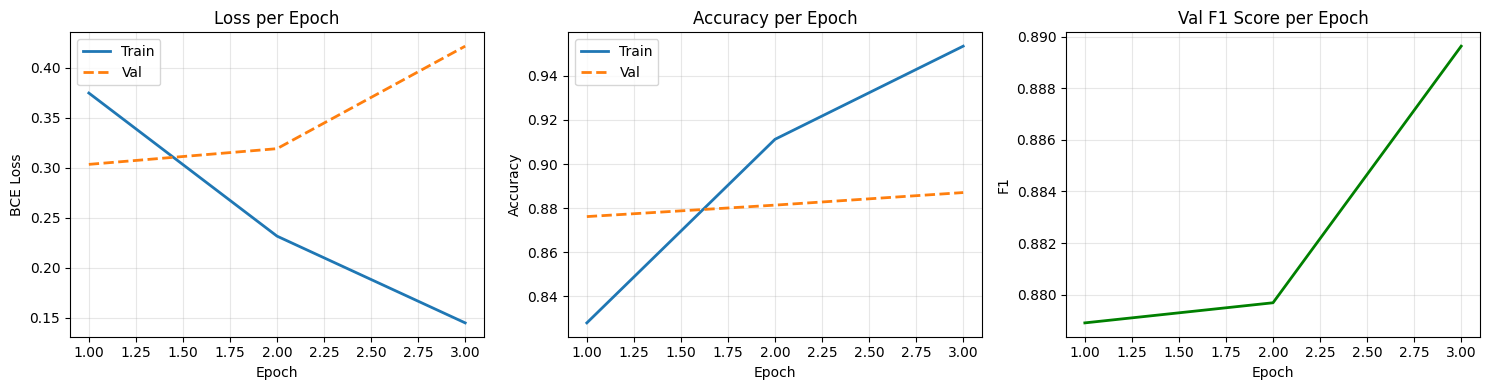

In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['val_f1'], color='green', linewidth=2)
axes[2].set_title('Val F1 Score per Epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_distilbert.png', dpi=150)
plt.show()


### Final Test Evaluation

In [14]:
final_metrics, y_pred, y_true, y_probs = eval_epoch(model, test_loader, criterion)

print("── Final Test Metrics ─────────────────────────────")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\n── Classification Report ──────────────────────────")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

── Final Test Metrics ─────────────────────────────
  loss        : 0.3035
  accuracy    : 0.8762
  precision   : 0.8665
  recall      : 0.8916
  f1          : 0.8789

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87      4961
    Positive       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000




### Confusion Matrix

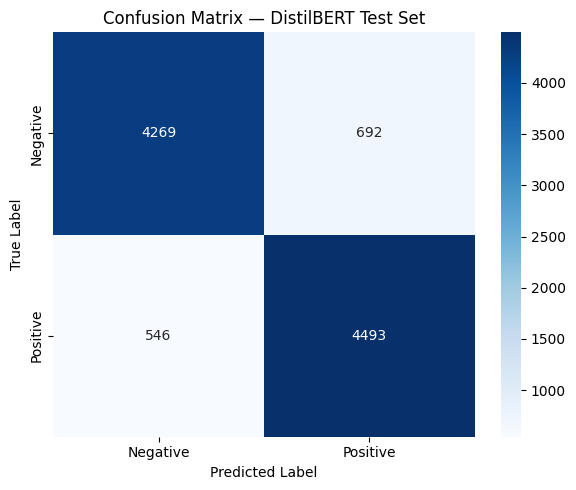

TN=4269  FP=692  FN=546  TP=4493


In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — DistilBERT Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")


### ROC Curve & AUC

Optimal decision threshold: 0.568
AUC: 0.9503


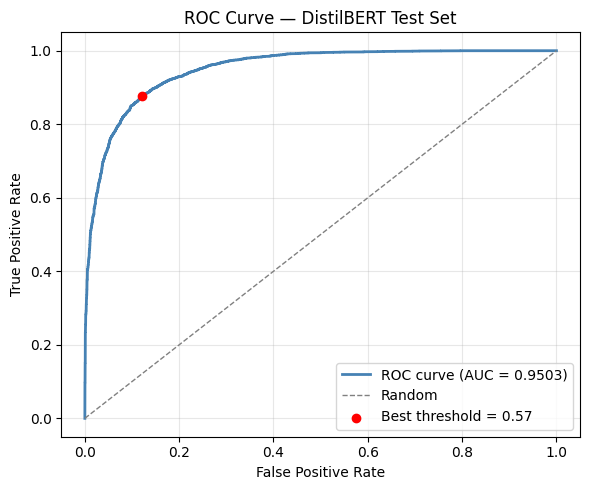

In [16]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
print(f"Optimal decision threshold: {best_thresh:.3f}")
print(f"AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — DistilBERT Test Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_distilbert.png', dpi=150)
plt.show()


### Inference on Custom Text

In [17]:
def predict_sentiment(review_text: str, threshold: float = 0.5) -> dict:
    """
    Predict sentiment for a single raw review string using DistilBERT.
    """
    model.eval()
    encoding = tokenizer(
        review_text,
        max_length     = MAX_LEN,
        truncation     = True,
        padding        = 'max_length',
        return_tensors = 'pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        prob = model(input_ids, attention_mask).item()

    label = 'Positive' if prob >= threshold else 'Negative'
    conf  = prob if prob >= threshold else 1 - prob
    return {'label': label, 'probability': round(prob, 4), 'confidence': round(conf, 4)}


samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of two hours. The plot made no sense at all.",
    "It was okay, nothing special but not bad either."
]

for text in samples:
    result = predict_sentiment(text)
    print(f"[{result['label']}] (p={result['probability']}, conf={result['confidence']})")
    print(f"  → {text[:70]}...\n")

[Positive] (p=0.9937, conf=0.9937)
  → This movie was absolutely fantastic! The acting was superb....

[Negative] (p=0.0026, conf=0.9974)
  → Terrible film. Waste of two hours. The plot made no sense at all....

[Positive] (p=0.6111, conf=0.6111)
  → It was okay, nothing special but not bad either....




### Save Model

In [18]:
torch.save(model.state_dict(), 'sentiment_model_distilbert.pt')
print("Model saved → sentiment_model_distilbert.pt")

# To reload later:
# loaded_model = SentimentDistilBERT().to(device)
# loaded_model.load_state_dict(torch.load('sentiment_model_distilbert.pt'))
# loaded_model.eval()

Model saved → sentiment_model_distilbert.pt
